In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.datasets import load_breast_cancer

# ── Dataset 1: Heart Disease (your original) ──────────────────
df_heart = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
print("Heart Disease:", df_heart.shape)
print(df_heart.isnull().sum().sum(), "missing values")
print(df_heart['target'].value_counts())
print()

# ── Dataset 2: Diabetes ───────────────────────────────────────
# Add Data on Kaggle → search "pima indians diabetes" → uciml/pima-indians-diabetes-database
df_diab = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
print("Diabetes:", df_diab.shape)
print(df_diab.isnull().sum().sum(), "missing values")
print(df_diab['Outcome'].value_counts())
print()

# ── Dataset 3: Breast Cancer (built into sklearn) ─────────────
bc    = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc['target'] = bc.target
print("Breast Cancer:", df_bc.shape)
print(df_bc['target'].value_counts())

Heart Disease: (1025, 14)
0 missing values
target
1    526
0    499
Name: count, dtype: int64

Diabetes: (768, 9)
0 missing values
Outcome
0    500
1    268
Name: count, dtype: int64

Breast Cancer: (569, 31)
target
1    357
0    212
Name: count, dtype: int64


In [2]:
# Quick summary of all 3 loaded datasets
for name, df, col in [('Heart Disease', df_heart, 'target'),
                       ('Diabetes',      df_diab,  'Outcome'),
                       ('Breast Cancer', df_bc,    'target')]:
    print(f"{'─'*45}")
    print(f"Dataset : {name}")
    print(f"Shape   : {df.shape}")
    print(f"Missing : {df.isnull().sum().sum()}")
    print(f"Classes : {df[col].value_counts().to_dict()}")
print(f"{'─'*45}")
print("All datasets ready ✅")

─────────────────────────────────────────────
Dataset : Heart Disease
Shape   : (1025, 14)
Missing : 0
Classes : {1: 526, 0: 499}
─────────────────────────────────────────────
Dataset : Diabetes
Shape   : (768, 9)
Missing : 0
Classes : {0: 500, 1: 268}
─────────────────────────────────────────────
Dataset : Breast Cancer
Shape   : (569, 31)
Missing : 0
Classes : {1: 357, 0: 212}
─────────────────────────────────────────────
All datasets ready ✅


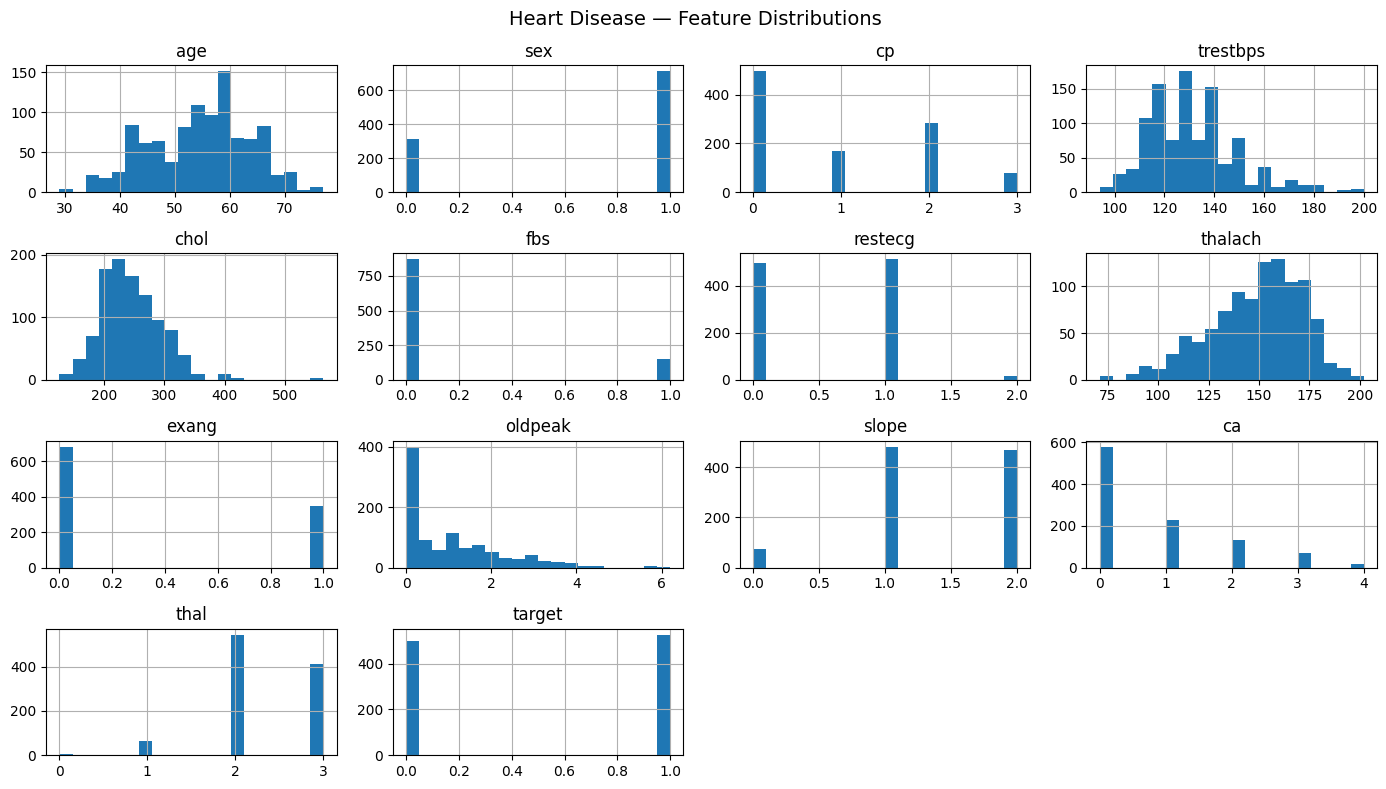

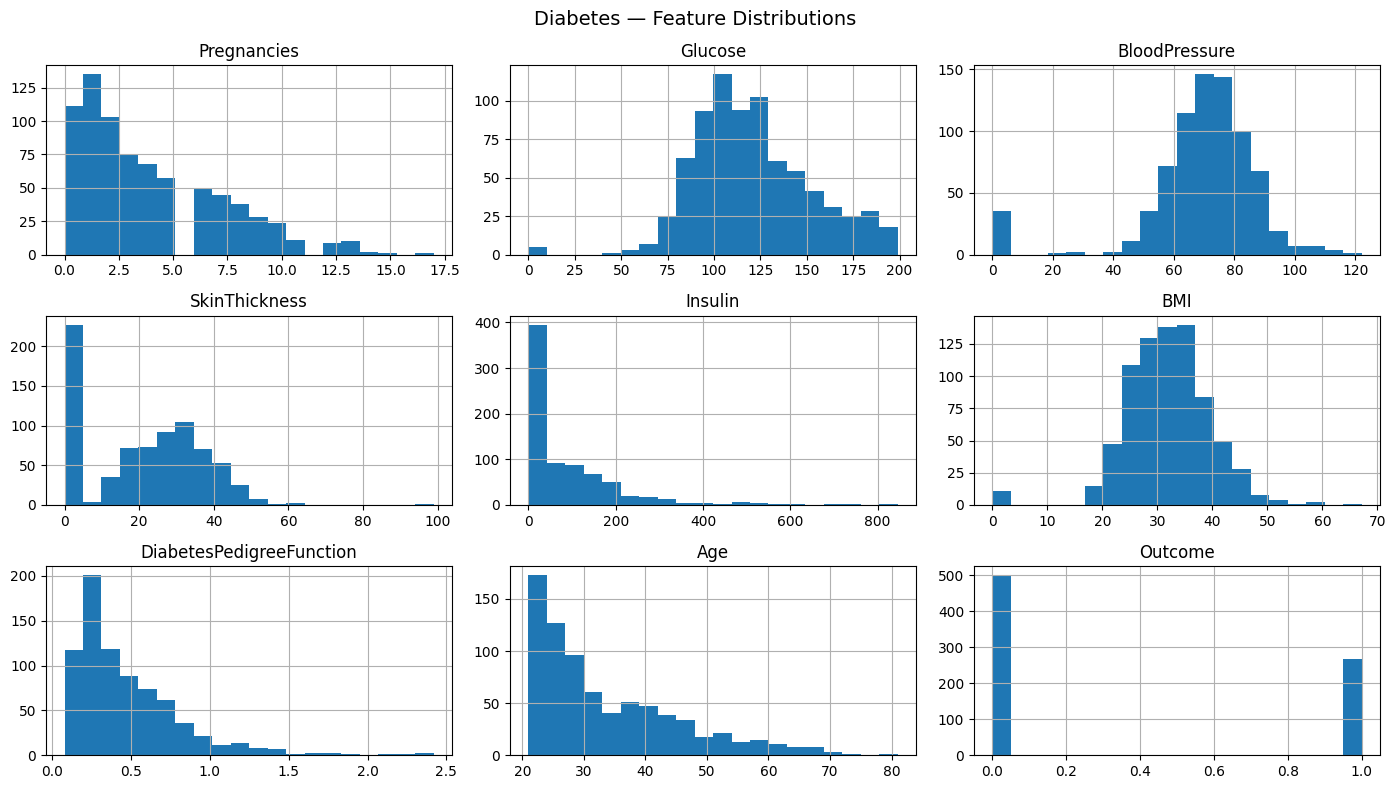

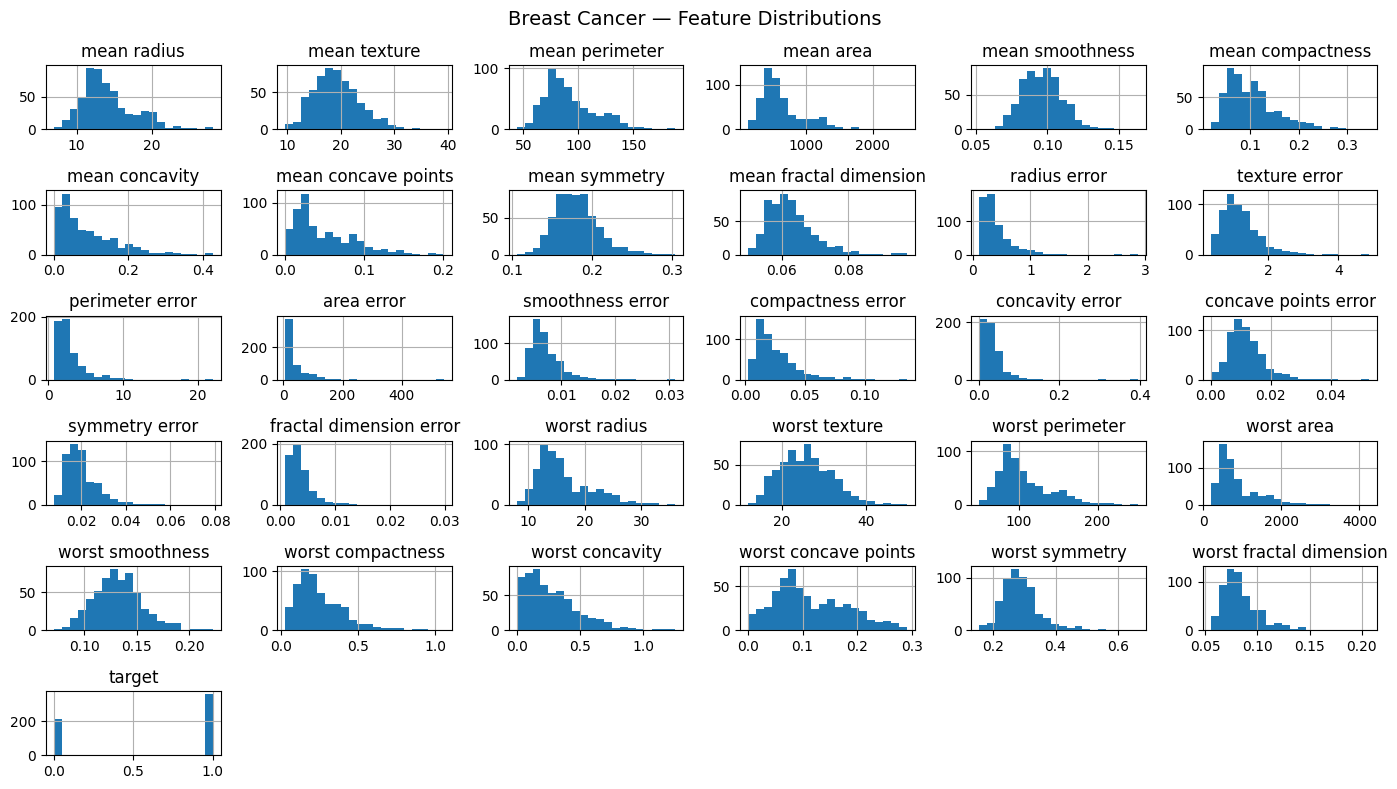

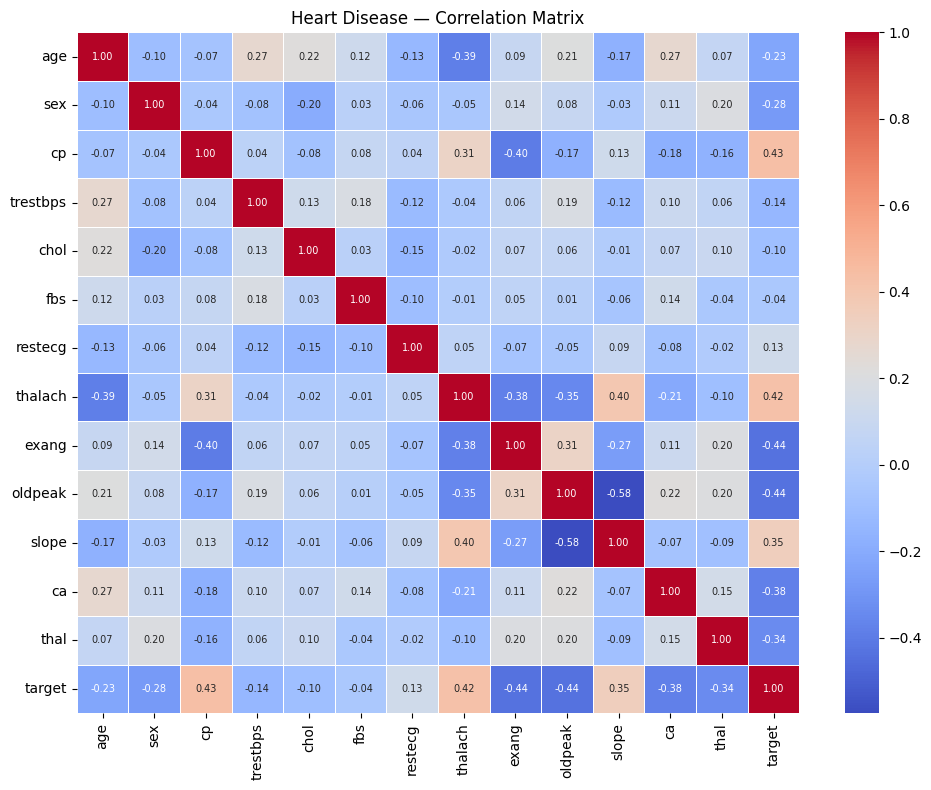

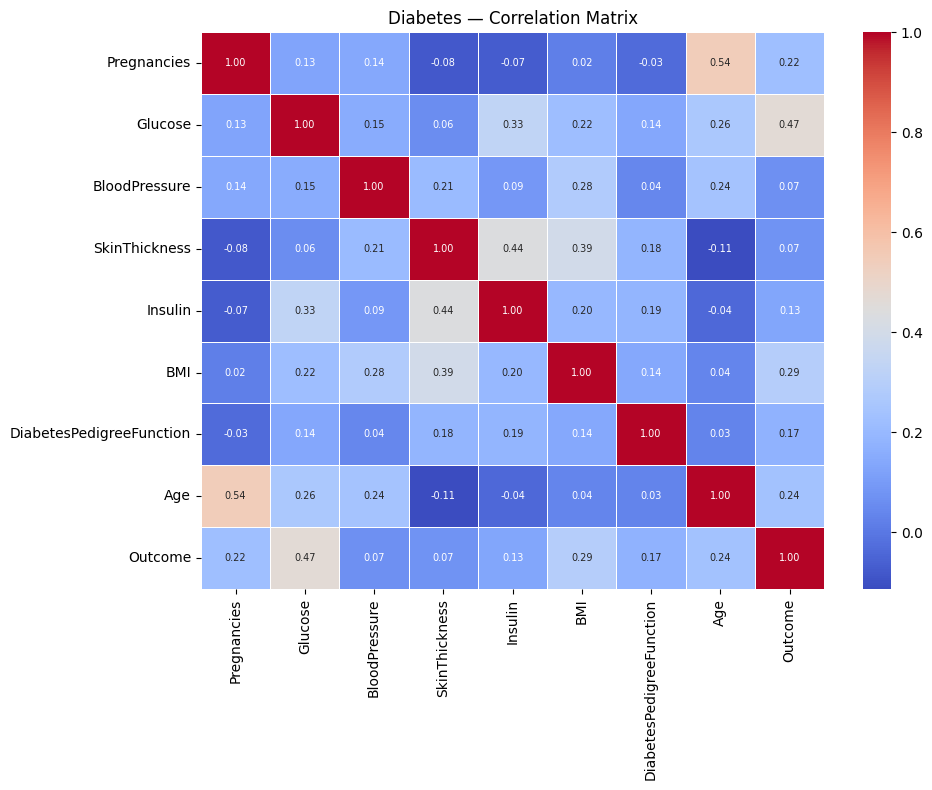

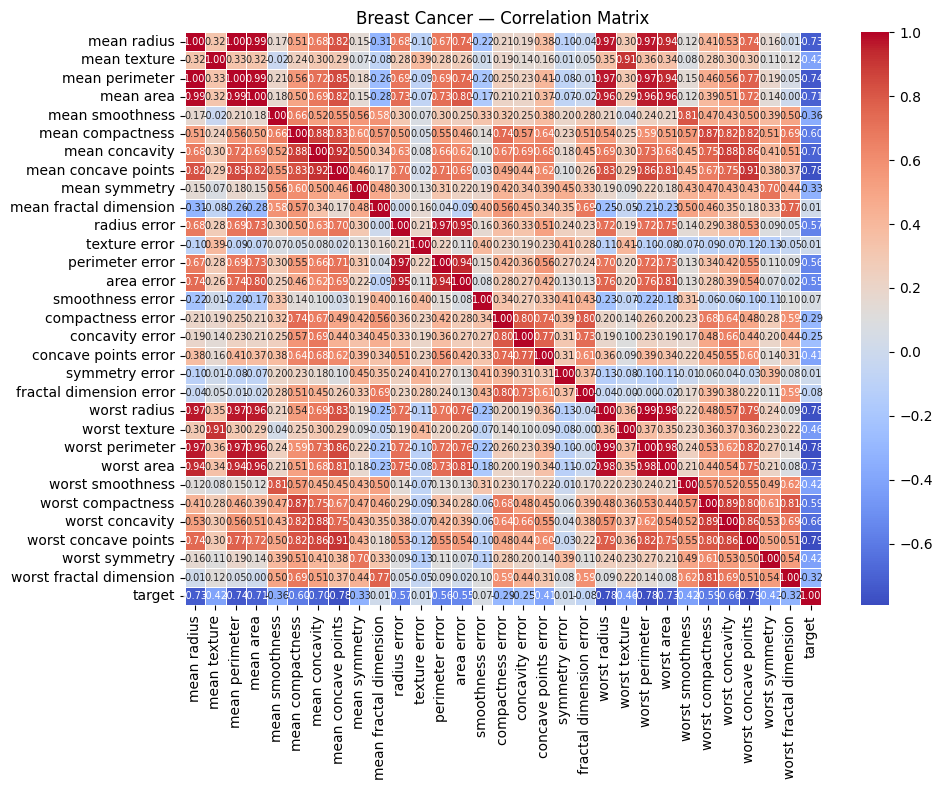

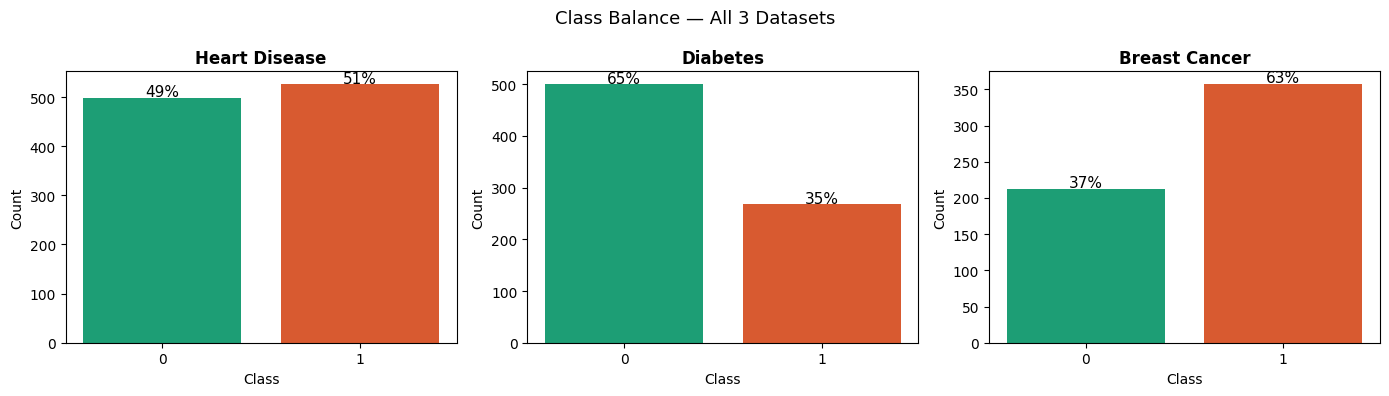

In [3]:
datasets = [
    (df_heart, 'target',  'Heart Disease'),
    (df_diab,  'Outcome', 'Diabetes'),
    (df_bc,    'target',  'Breast Cancer'),
]

# ── Histograms ────────────────────────────────────────────────
for df, col, title in datasets:
    df.hist(bins=20, figsize=(14, 8))
    plt.suptitle(f'{title} — Feature Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()

# ── Correlation heatmaps ──────────────────────────────────────
for df, col, title in datasets:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, fmt='.2f',
                cmap='coolwarm', linewidths=0.4,
                annot_kws={'size': 7})
    plt.title(f'{title} — Correlation Matrix')
    plt.tight_layout()
    plt.show()

# ── Class balance (all 3 side by side) ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, col, title) in zip(axes, datasets):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=['#1D9E75', '#D85A30'])
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, f'{v/len(df)*100:.0f}%', ha='center', fontsize=11)
plt.suptitle('Class Balance — All 3 Datasets', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
def run_pipeline(df, target_col, dataset_name):
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    neg, pos = y_train.value_counts().max(), y_train.value_counts().min()

    models = {
        'Logistic Regression': (LogisticRegression(max_iter=1000), True),
        'Random Forest':       (RandomForestClassifier(n_estimators=100,
                                random_state=42), False),
        'SVM':                 (SVC(kernel='rbf', probability=True), True),
        'XGBoost':             (XGBClassifier(n_estimators=100,
                                learning_rate=0.1, scale_pos_weight=neg/pos,
                                eval_metric='logloss', verbosity=0), False),
    }

    results = []
    trained = {}
    for name, (model, scaled) in models.items():
        Xtr = X_train_sc if scaled else X_train
        Xte = X_test_sc  if scaled else X_test
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
        results.append({
            'Dataset':  dataset_name,
            'Model':    name,
            'Accuracy': round(accuracy_score(y_test, preds), 3),
            'F1':       round(f1_score(y_test, preds), 3),
            'ROC-AUC':  round(roc_auc_score(y_test, proba), 3),
        })
        trained[name] = (model, scaled, X_test_sc, X_test, y_test)

    return results, trained

# ── Run on all 3 ──────────────────────────────────────────────
all_results = []

print("Training on Heart Disease...")
r1, t1 = run_pipeline(df_heart, 'target',  'Heart Disease')
all_results.extend(r1)

print("Training on Diabetes...")
r2, t2 = run_pipeline(df_diab,  'Outcome', 'Diabetes')
all_results.extend(r2)

print("Training on Breast Cancer...")
r3, t3 = run_pipeline(df_bc,    'target',  'Breast Cancer')
all_results.extend(r3)

print("\nAll training complete ✅")

Training on Heart Disease...
Training on Diabetes...
Training on Breast Cancer...

All training complete ✅


MASTER RESULTS — All Models × All Datasets
      Dataset               Model  Accuracy    F1  ROC-AUC
Heart Disease Logistic Regression     0.810 0.831    0.930
Heart Disease       Random Forest     1.000 1.000    1.000
Heart Disease                 SVM     0.927 0.930    0.977
Heart Disease             XGBoost     1.000 1.000    1.000
     Diabetes Logistic Regression     0.714 0.560    0.823
     Diabetes       Random Forest     0.760 0.634    0.812
     Diabetes                 SVM     0.753 0.635    0.792
     Diabetes             XGBoost     0.753 0.655    0.825
Breast Cancer Logistic Regression     0.982 0.986    0.995
Breast Cancer       Random Forest     0.956 0.966    0.994
Breast Cancer                 SVM     0.982 0.986    0.995
Breast Cancer             XGBoost     0.947 0.959    0.992


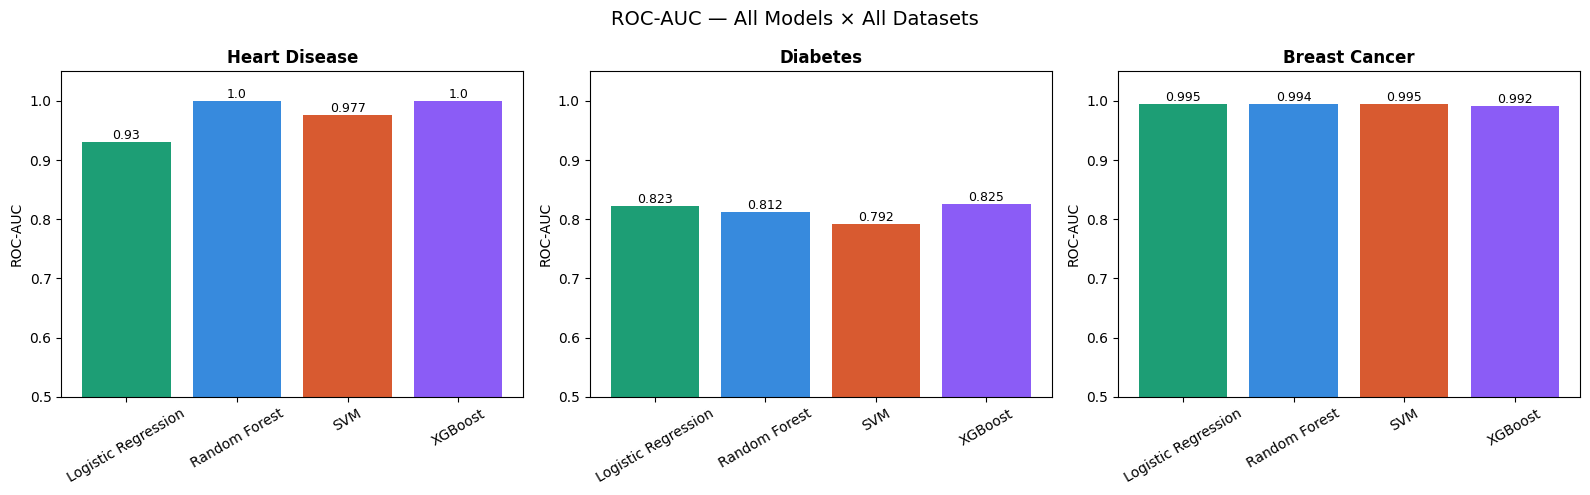

In [5]:
results_df = pd.DataFrame(all_results)

# Print table
print("=" * 62)
print("MASTER RESULTS — All Models × All Datasets")
print("=" * 62)
print(results_df.to_string(index=False))

# Grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#1D9E75', '#378ADD', '#D85A30', '#8B5CF6']

for ax, ds in zip(axes, ['Heart Disease', 'Diabetes', 'Breast Cancer']):
    subset = results_df[results_df['Dataset'] == ds]
    bars   = ax.bar(subset['Model'], subset['ROC-AUC'], color=colors)
    ax.set_title(ds, fontweight='bold')
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('ROC-AUC')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, subset['ROC-AUC']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                str(val), ha='center', fontsize=9)

plt.suptitle('ROC-AUC — All Models × All Datasets', fontsize=14)
plt.tight_layout()
plt.show()

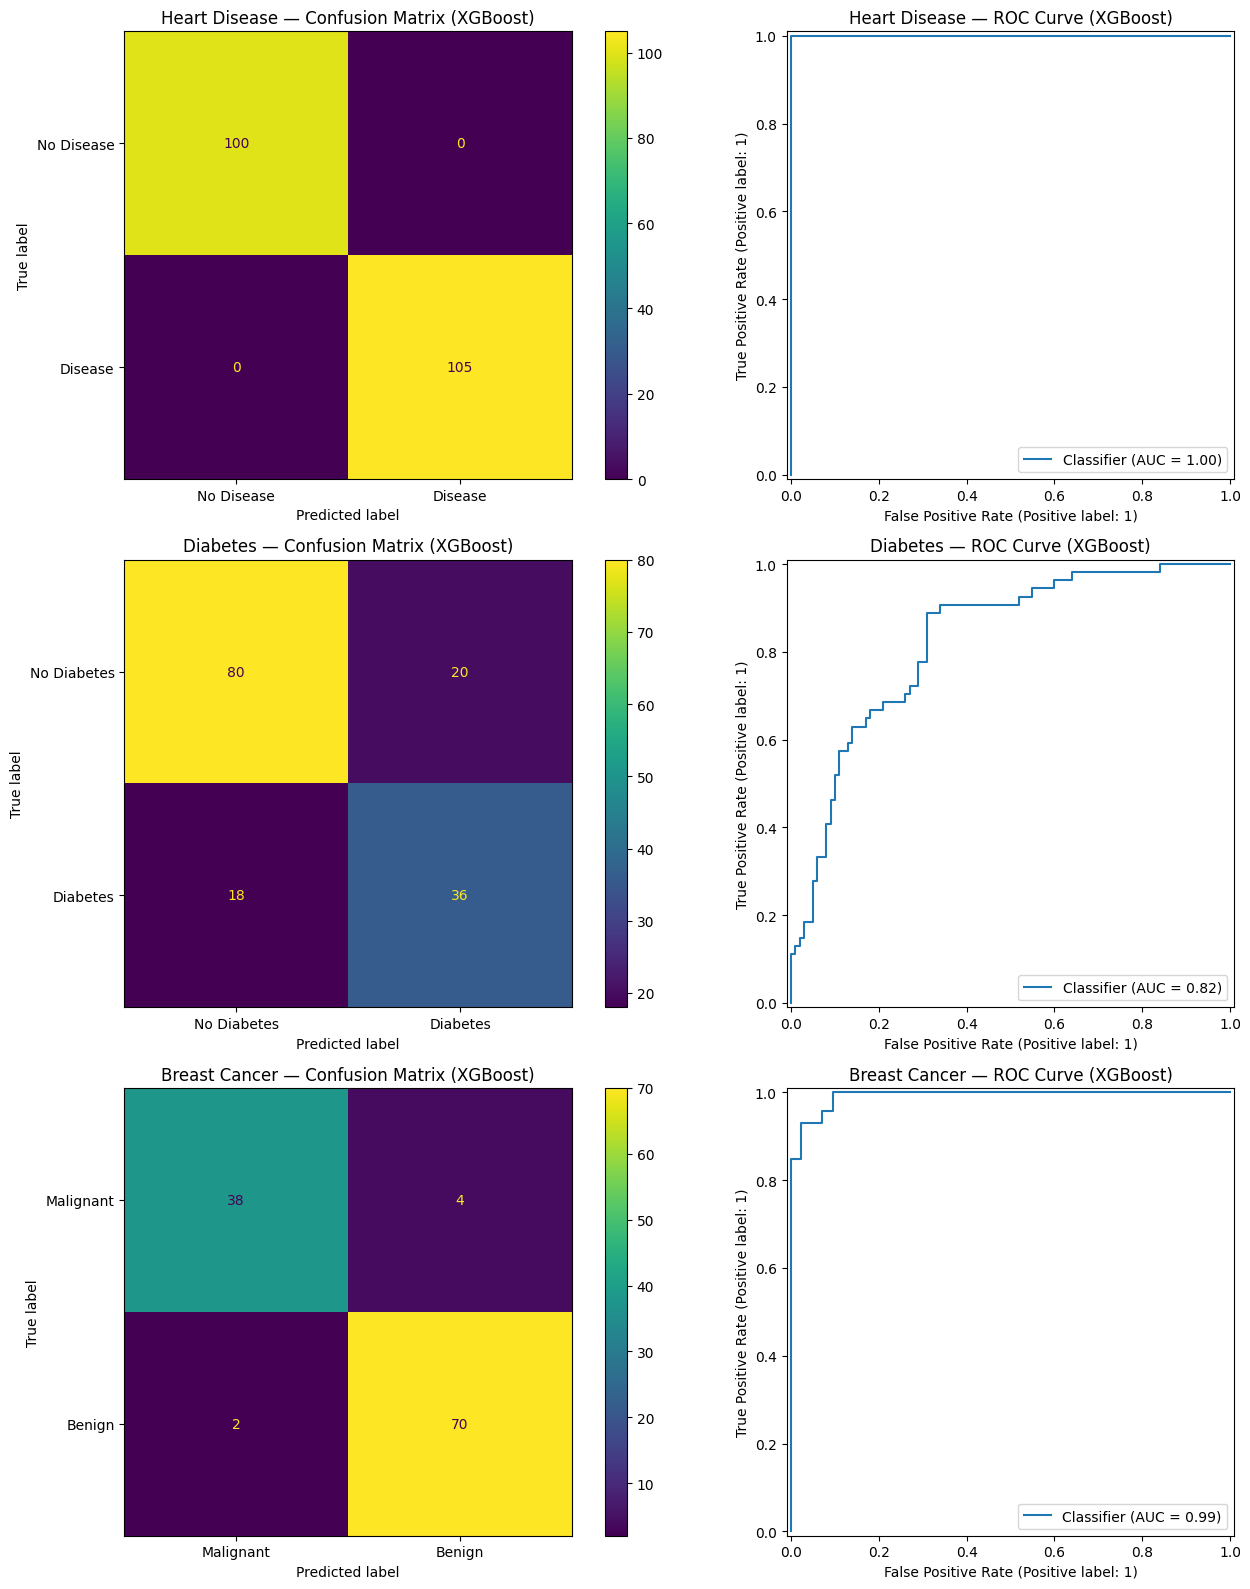

In [6]:
trained_sets = [
    (t1, 'Heart Disease',  ['No Disease',  'Disease']),
    (t2, 'Diabetes',       ['No Diabetes', 'Diabetes']),
    (t3, 'Breast Cancer',  ['Malignant',   'Benign']),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for row, (trained, ds_name, labels) in enumerate(trained_sets):
    model, scaled, X_test_sc, X_test, y_test = trained['XGBoost']
    Xte   = X_test_sc if scaled else X_test
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, ax=axes[row][0], display_labels=labels)
    axes[row][0].set_title(f'{ds_name} — Confusion Matrix (XGBoost)')

    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[row][1])
    axes[row][1].set_title(f'{ds_name} — ROC Curve (XGBoost)')

plt.tight_layout()
plt.show()

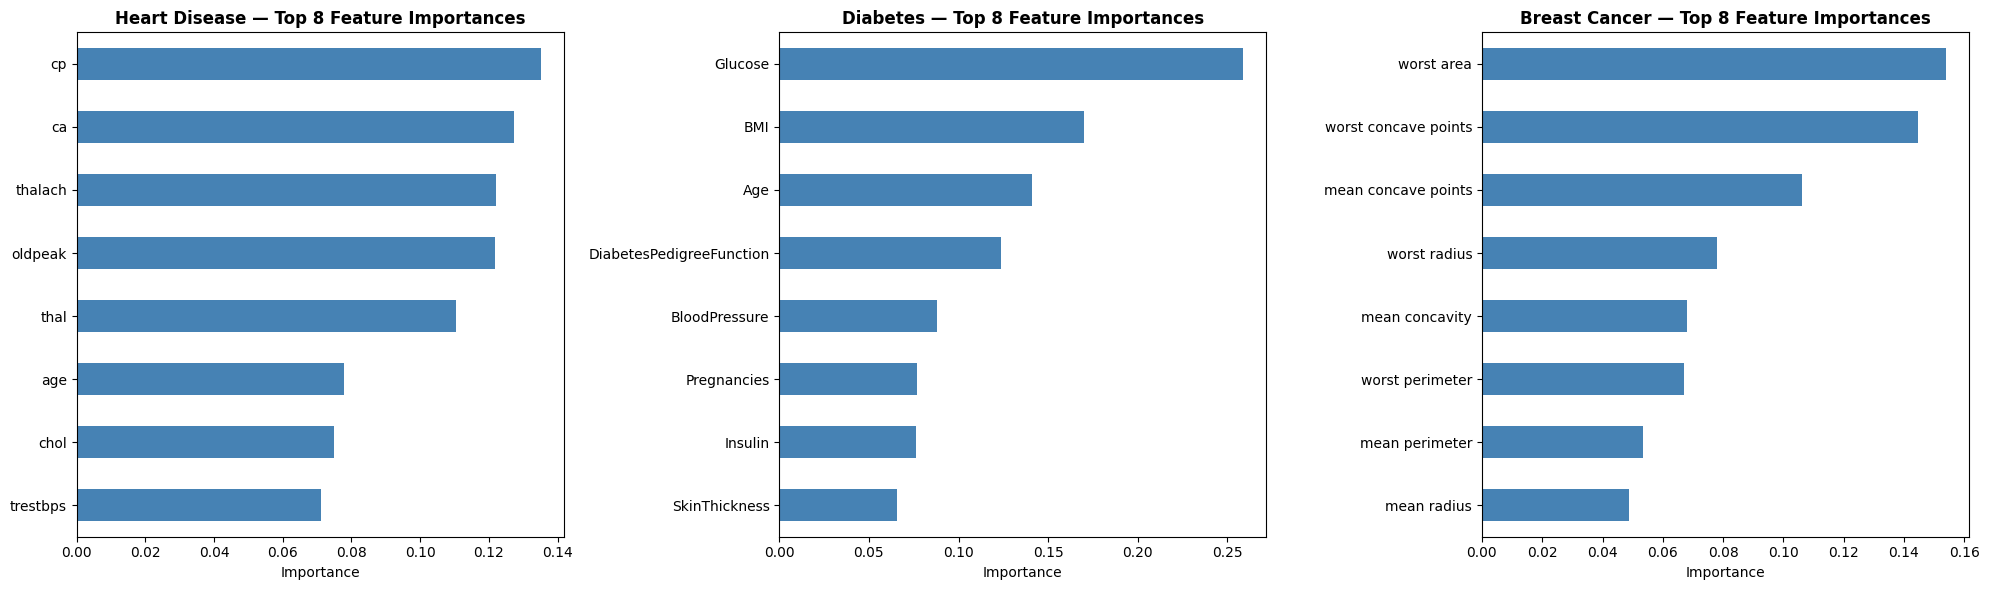

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (df, col, title) in zip(axes, datasets):
    X = df.drop(col, axis=1)
    y = df[col]
    X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
    feat_imp.sort_values(ascending=True).tail(8).plot(
        kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{title} — Top 8 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()